# Introduction to Portfolio Theory: Prices vs. Returns #

Andrea is a fifth-semester economics student trying to know more about capital markets. For this quest, she decided to invest some dollars in the stock market to create some returns over time. Her best friend, Gabriel, told her that NVidia and Amazon both were good ideas for a first investment, but she has a limited budget, so she can only pick one. What would you do in Andrea's shoes?

In [36]:
# Import Libraries

# Data Management
import pandas as pd
import numpy as np

# Statistics
from scipy.stats import probplot
from scipy.stats import skew, kurtosis
from scipy.stats import norm
from scipy.stats import chi2
from scipy.stats import jarque_bera
from scipy.stats import anderson

# Visualization
import matplotlib.pyplot as plt

# Handle Files
import sys
import os

# Import Local Functions
sys.path.append(os.path.abspath("../source"))
from config import get_tickers
from data_downloader import get_market_data

The `get_market_data` function is defined in the `data_downloader.py` script, located in the `source` folder. There, you can see how we constructed the data import function. Additionally, in the `config.toml` file within the `config` folder, you can set the data provider you want to use for this workshop. Please note that some of the available providers require an API key to access the data; you can also set your API key in that file.

Also, you can set the desired tickers for each notebook in the `tickers.toml` file within the `config` folder. 

In [2]:
tickers = get_tickers(mod="1.1")

tickers

['AMZN', 'NVDA']

In [3]:
# DataFrame to store everything
df_prices = pd.DataFrame()

for ticker in tickers:
    df = get_market_data(
        ticker=ticker, 
        start_date='2010-01-01', 
        end_date='2025-01-01', 
        returns=False
    )
    
    prices = df['close'].rename(ticker)
    
    df_prices = pd.concat([df_prices, prices], axis=1)
    
    print(f'Data Ready for {ticker}')

Data Ready for AMZN
Data Ready for NVDA


In [4]:
df_prices

,AMZN,NVDA
2010-01-04 00:00:00,6.695000,0.423854
2010-01-05 00:00:00,6.734500,0.430044
2010-01-06 00:00:00,6.612500,0.432794
2010-01-07 00:00:00,6.500000,0.424313
2010-01-08 00:00:00,6.676000,0.425230
...,...,...
2024-12-24 00:00:00,229.050003,140.197372
2024-12-26 00:00:00,227.050003,139.907410
2024-12-27 00:00:00,223.750000,136.987869
2024-12-30 00:00:00,221.300003,137.467804


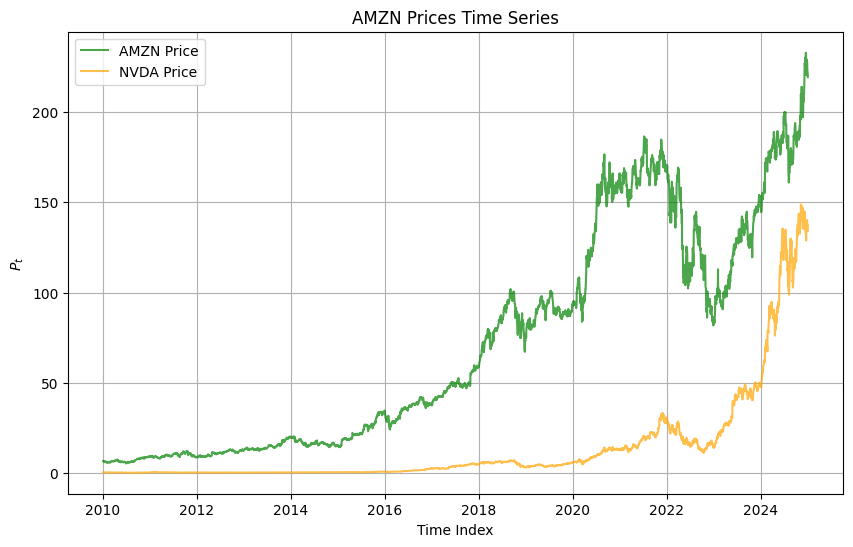

In [5]:
# Time Series Graphs for Adjusted Close Prices
plt.figure(figsize=(10, 6))
plt.plot(df_prices['AMZN'], label='AMZN Price', color='green', alpha=0.7)
plt.plot(df_prices['NVDA'], label='NVDA Price', color='orange', alpha=0.7)

# Config
plt.title('AMZN Prices Time Series')
plt.xlabel('Time Index')
plt.ylabel('$P_t$')
plt.legend()

# Show
plt.grid(True)
plt.show()

By watching this graph, Andrea might conclude Amazon was the best investment because its price was always higher than Nvidia's. But that is a common bias many people fall into. The reality is that we do not have to check price lines, but the slopes of these. That is why we use returns: the change (in percentage) of prices over time.

The following chart shows the comparison between both stocks' cumulative returns. Hence, we can conclude that, by holding an Nvidia stock from 2018 to the end of 2024, she would have more than quintupled her money. In Amazon's case, by holding a stock during the same time, Nancy would have less than tripled her money.

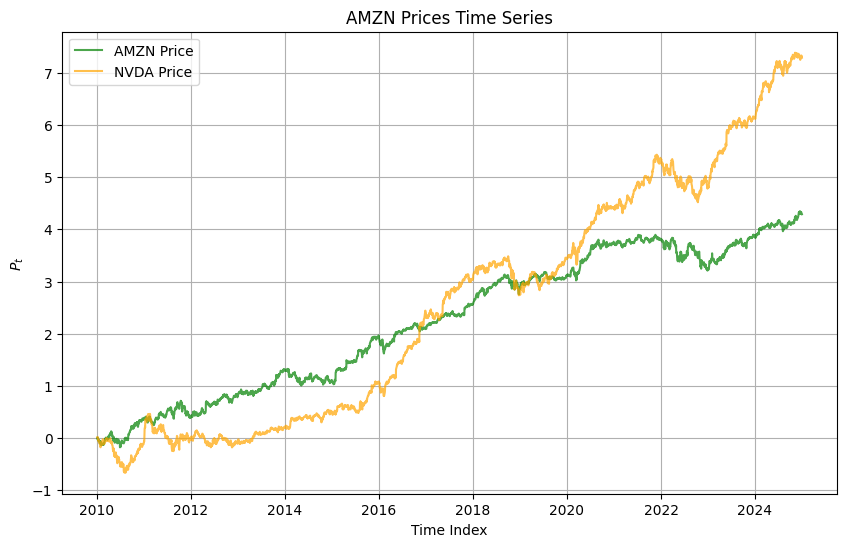

In [6]:
# Time Series Graphs for Cumulative Returns
plt.figure(figsize=(10, 6))
plt.plot(df_prices['AMZN'].pct_change().cumsum(), label='AMZN Price', color='green', alpha=0.7)
plt.plot(df_prices['NVDA'].pct_change().cumsum(), label='NVDA Price', color='orange', alpha=0.7)

# Config
plt.title('AMZN Prices Time Series')
plt.xlabel('Time Index')
plt.ylabel('$P_t$')
plt.legend()

# Show
plt.grid(True)
plt.show()

Nevertheless, prices do matter, especially if you are creating a naive investment strategy. For example, let us assume Andrea has 100 dollars available for purchasing in 2018. How many Amazon shares and how many Nvidia shares can she purchase with that money? And after that, how much money will she generate after she sells her stocks in 2024?

In [7]:
# Let us get the prices of each stock at t=0
amzn_first_p = df_prices['AMZN'].iloc[0]
nvda_first_p = df_prices['NVDA'].iloc[0]

print(f'AMZN price in t=0: {amzn_first_p}')
print(f'NVDA price in t=0: {nvda_first_p}')

AMZN price in t=0: 6.695000171661377
NVDA price in t=0: 0.4238542914390564


In [8]:
# Now, let us calculate how much stocks can Nancy purchase in t = 0
amzn_purchased_stocks = 100 // amzn_first_p    # We use "//" for integer division
nvda_purchased_stocks = 100 // nvda_first_p

print(f'AMZN purchased stocks: {amzn_purchased_stocks}')
print(f'NVDA purchased stocks: {nvda_purchased_stocks}')

AMZN purchased stocks: 14.0
NVDA purchased stocks: 235.0


Gabriel recommends Andrea to invest the leftover money in Treasury bonds, assuming a constant annual yield of 4%.

In [9]:
# Calculate the leftover money
amzn_leftover = 100 - (amzn_purchased_stocks * amzn_first_p)
nvda_leftover = 100 - (nvda_purchased_stocks * nvda_first_p)

print(f'AMZN leftover: {amzn_leftover}')
print(f'NVDA leftover: {nvda_leftover}')

AMZN leftover: 6.269997596740723
NVDA leftover: 0.3942415118217468


Now we can calculate the returns generated by Andrea from January 1st, 2018, to December 31st, 2024. Then, we will sum the returns generated by the stocks in each case and the interest generated by the bonds.

In [10]:
# Calculate the Last Prices of Each stock
amzn_last_p = df_prices['AMZN'].iloc[-1]
nvda_last_p = df_prices['NVDA'].iloc[-1]

print(f'AMZN last price: {amzn_last_p}')
print(f'NVDA last price: {nvda_last_p}')

AMZN last price: 219.38999938964844
NVDA last price: 134.26832580566406


In [11]:
# Now calculate the amount of money generated during the period
amzn_monetary_returns = (amzn_last_p - amzn_first_p) * amzn_purchased_stocks
amzn_leftover_interests = amzn_leftover * 1.04 ** 6  # Six years

# Sum
first_investment_returns = amzn_monetary_returns + amzn_leftover_interests

print(f'AMZN monetary returns: {amzn_monetary_returns}')
print(f'Interests Generated by Left Over: {amzn_leftover_interests}')
print(f'Strategy Returns: {first_investment_returns}')

AMZN monetary returns: 2977.729989051819
Interests Generated by Left Over: 7.933547205080252
Strategy Returns: 2985.663536256899


In [12]:
# Now for Nvidia
nvda_monetary_returns = (nvda_last_p - nvda_first_p) * nvda_purchased_stocks
nvda_leftover_interests = nvda_leftover * 1.04 ** 6

# Sum
second_investment_returns = nvda_monetary_returns + nvda_leftover_interests

print(f'NVDA monetary returns: {nvda_monetary_returns}')
print(f'Interest Generated by Left Over: {nvda_leftover_interests}')
print(f'Strategy Returns: {second_investment_returns}')

NVDA monetary returns: 31453.450805842876
Interest Generated by Left Over: 0.498841282788672
Strategy Returns: 31453.949647125664


In [13]:
# Calculate the rate of returns
first_case_returns_rate = (first_investment_returns / 100) - 1
second_case_returns_rate = (second_investment_returns / 100) - 1

print(f'If Nancy would have pick AMZN: {first_case_returns_rate*100}%')
print(f'If Nancy would have pick NVDA: {second_case_returns_rate*100}%')

If Nancy would have pick AMZN: 2885.663536256899%
If Nancy would have pick NVDA: 31353.949647125664%


In the universe where Andrea purchased NVDA, she is now having a great graduation trip in a tropical paradise.

### Logarithmic Returns vs. Arithmetic Returns ###

It is a common dichotomy in the study of finance to choose between arithmetic returns and logarithmic returns. Even though the first may be more intuitive for people, the latter grant us a lot of favorable properties that enhance our financial models.

Arithmetic Returns:
\begin{aligned}
$$ R_t = \frac{P_{t} - P_{t-1}}{P_{t-1}} = \frac{P_t}{P_{t-1}} - 1$$
\end{aligned}

Logarithmic Returns: 
\begin{aligned}
$$r_t = \ln{\left(\frac{P_t}{P_{t-1}}\right)} = \ln{P_t} - \ln{P_{t-1}}$$
\end{aligned}

These concepts are explored in the first section of this moudle's PDF.

In [14]:
# Let us calculate the returns and log returns
df_arithmetic_returns = df_prices.pct_change(1)

df_arithmetic_returns

,AMZN,NVDA
2010-01-04 00:00:00,NaN,NaN
2010-01-05 00:00:00,0.005900,0.014602
2010-01-06 00:00:00,-0.018116,0.006397
2010-01-07 00:00:00,-0.017013,-0.019598
2010-01-08 00:00:00,0.027077,0.002161
...,...,...
2024-12-24 00:00:00,0.017729,0.003938
2024-12-26 00:00:00,-0.008732,-0.002068
2024-12-27 00:00:00,-0.014534,-0.020868
2024-12-30 00:00:00,-0.010950,0.003503


In [15]:
# Log Returns
df_logarithmic_returns = np.log(df_prices / df_prices.shift(1))

df_logarithmic_returns

,AMZN,NVDA
2010-01-04 00:00:00,NaN,NaN
2010-01-05 00:00:00,0.005883,0.014497
2010-01-06 00:00:00,-0.018282,0.006376
2010-01-07 00:00:00,-0.017160,-0.019792
2010-01-08 00:00:00,0.026717,0.002159
...,...,...
2024-12-24 00:00:00,0.017573,0.003930
2024-12-26 00:00:00,-0.008770,-0.002070
2024-12-27 00:00:00,-0.014641,-0.021088
2024-12-30 00:00:00,-0.011010,0.003497


Mathematically, it is proven that logarithmic returns will always be lower than arithmetic returns if $ (1 + R_t) > 0 $.

However, logarithmic returns possess other characteristics that are beneficial for us:
- Additive
- Symmetric

Check the PDF for more information.

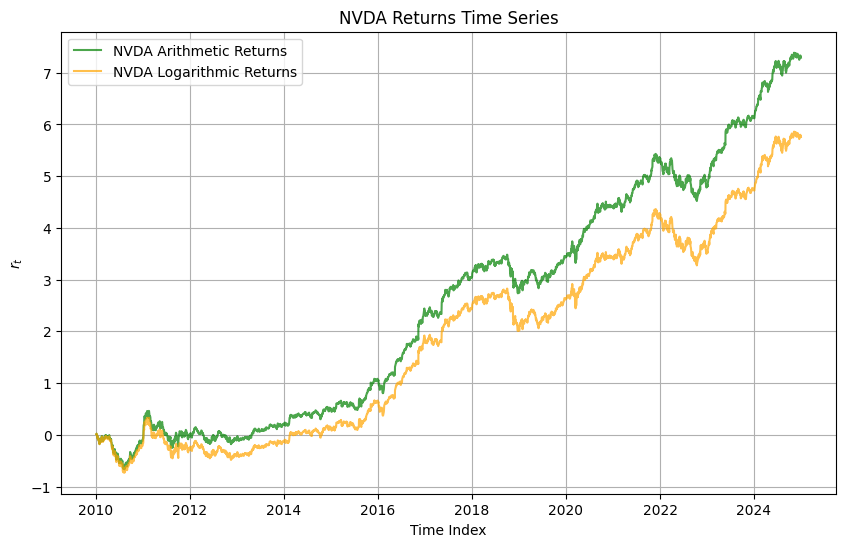

In [16]:
# Time Series Graphs for Cumulative Simple Returns and Log

plt.figure(figsize=(10, 6))
plt.plot(df_arithmetic_returns['NVDA'].cumsum(), label='NVDA Arithmetic Returns', color='green', alpha=0.7)
plt.plot(df_logarithmic_returns['NVDA'].cumsum(), label='NVDA Logarithmic Returns', color='orange', alpha=0.7)

# Config
plt.title('NVDA Returns Time Series')
plt.xlabel('Time Index')
plt.ylabel('$r_t$')
plt.legend()

# Show
plt.grid(True)
plt.show()

In the following plot, you can note that the range for the Arithmetic Returns is larger than the range for the Logarithmic Returns.

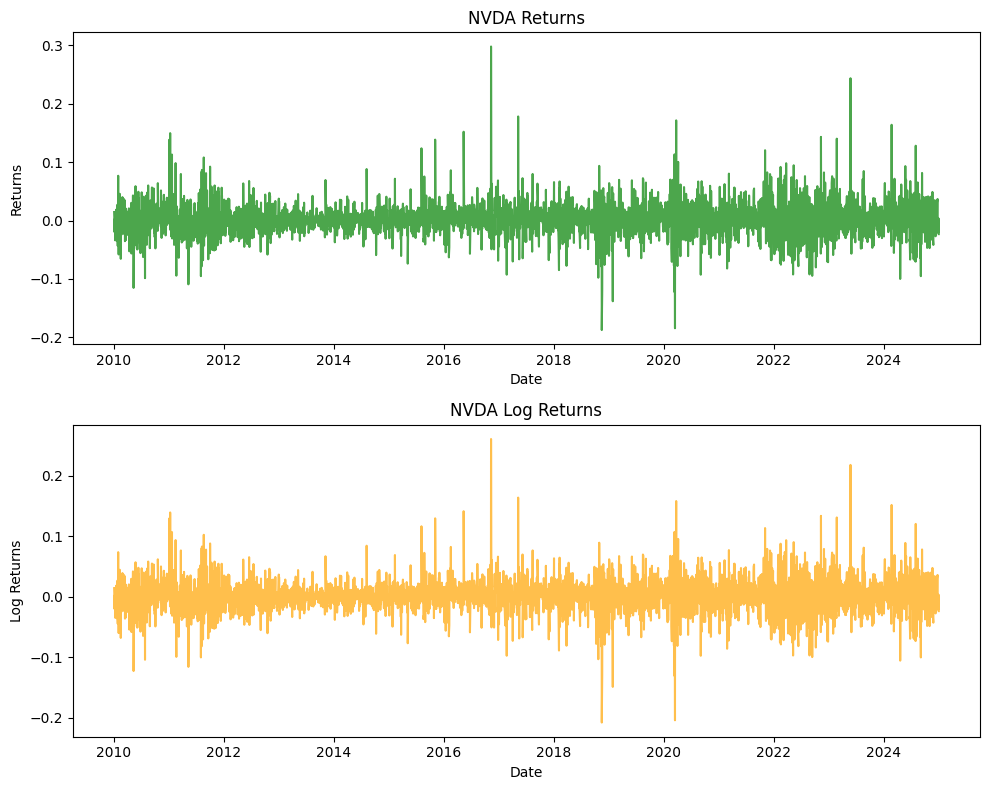

In [17]:
# Time Series Graphs
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

axes[0].plot(df_arithmetic_returns['NVDA'], color='green', alpha=0.7)
axes[0].set_title('NVDA Returns')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Returns')

axes[1].plot(df_logarithmic_returns['NVDA'], color='orange', alpha=0.7)
axes[1].set_title('NVDA Log Returns')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Log Returns')

plt.tight_layout()

plt.show()

The formulas of the forward concepts are located in the first section of this module's PDF.

In [18]:
# Let us check the mean returns
# AMZN
amzn_mean_rets = df_logarithmic_returns['AMZN'].mean()
amzn_annualized_mean_rets = amzn_mean_rets * 252

# NVDA
nvda_mean_rets = df_logarithmic_returns['NVDA'].mean()
nvda_annualized_mean_rets = nvda_mean_rets * 252

print(f'AMZN Mean Daily Returns: {(amzn_mean_rets * 100).round(2)}%')
print(f'AMZN Mean Annual Returns: {(amzn_annualized_mean_rets * 100).round(2)}%')
print(f'NVDA Mean Daily Returns: {(nvda_mean_rets * 100).round(2)}%')
print(f'NVDA Mean Annual Returns: {(nvda_annualized_mean_rets * 100).round(2)}%')

AMZN Mean Daily Returns: 0.09%
AMZN Mean Annual Returns: 23.31%
NVDA Mean Daily Returns: 0.15%
NVDA Mean Annual Returns: 38.46%


In [19]:
# And the Standard Deviations
# AMZN
amzn_std_rets = df_logarithmic_returns['AMZN'].std()
amzn_annualized_std_rets = amzn_std_rets * np.sqrt(252)

# NVDA
nvda_std_rets = df_logarithmic_returns['NVDA'].std()
nvda_annualized_std_rets = nvda_std_rets * np.sqrt(252)

print(f'AMZN Returns Daily Standard Deviation: {round(amzn_std_rets*100, 2)}%')
print(f'AMZN Returns Annualized Standard Deviation: {round(amzn_annualized_std_rets*100, 2)}%')
print(f'NVDA Returns Daily Standard Deviation: {round(nvda_std_rets*100, 2)}%')
print(f'NVDA Returns Annualized Standard Deviation: {round(nvda_annualized_std_rets*100, 2)}%')

AMZN Returns Daily Standard Deviation: 2.06%
AMZN Returns Annualized Standard Deviation: 32.65%
NVDA Returns Daily Standard Deviation: 2.84%
NVDA Returns Annualized Standard Deviation: 45.12%


In [20]:
# Cumulative Returns
# Arithmetic cumulative returns
c_arithmetic_rets = (1 + df_arithmetic_returns['NVDA']).cumprod() - 1
c_arithmetic_rets = c_arithmetic_rets

# Logarithmic cumulative returns
c_logarithmic_rets = df_logarithmic_returns['NVDA'].cumsum()

# Print final cumulative returns (rounded to 2 decimals)
print(f'NVDA Cumulative Arithmetic Returns: {(c_arithmetic_rets.iloc[-1] * 100):.2f}%')
print(f'NVDA Cumulative Logarithmic Returns: {(c_logarithmic_rets.iloc[-1] * 100):.2f}%')

NVDA Cumulative Arithmetic Returns: 31577.94%
NVDA Cumulative Logarithmic Returns: 575.82%


In [21]:
# The Compound Annual Growth Rate 
initial_vals = df_prices['NVDA'].iloc[0]
final_vals = df_prices['NVDA'].iloc[-1]

n = 6 # Six Years

# Calculate the CAGR
CAGR = np.power(final_vals / initial_vals, (1 / n)) - 1

print(f"The Compound Annual Growth Rate is: {(CAGR*100).round(2)}%")

The Compound Annual Growth Rate is: 161.09%


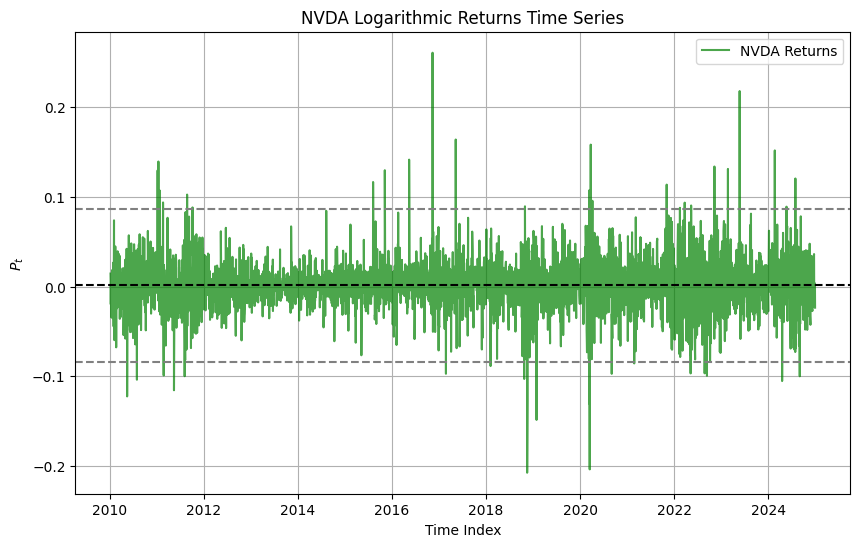

In [22]:
# Time Series Graphs to check Standard Deviation

upper_lim = df_logarithmic_returns['NVDA'].mean() + 3*df_logarithmic_returns['NVDA'].std()
lower_lim = df_logarithmic_returns['NVDA'].mean() - 3*df_logarithmic_returns['NVDA'].std()

plt.figure(figsize=(10, 6))
plt.plot(df_logarithmic_returns['NVDA'], label='NVDA Returns', color='green', alpha=0.7)
plt.axhline(y=df_logarithmic_returns['NVDA'].mean(), color='black', linestyle='dashed')
plt.axhline(y=upper_lim, color='grey', linestyle='dashed')
plt.axhline(y=lower_lim, color='grey', linestyle='dashed')

# Config
plt.title('NVDA Logarithmic Returns Time Series')
plt.xlabel('Time Index')
plt.ylabel('$P_t$')
plt.legend()

# Show
plt.grid(True)
plt.show()

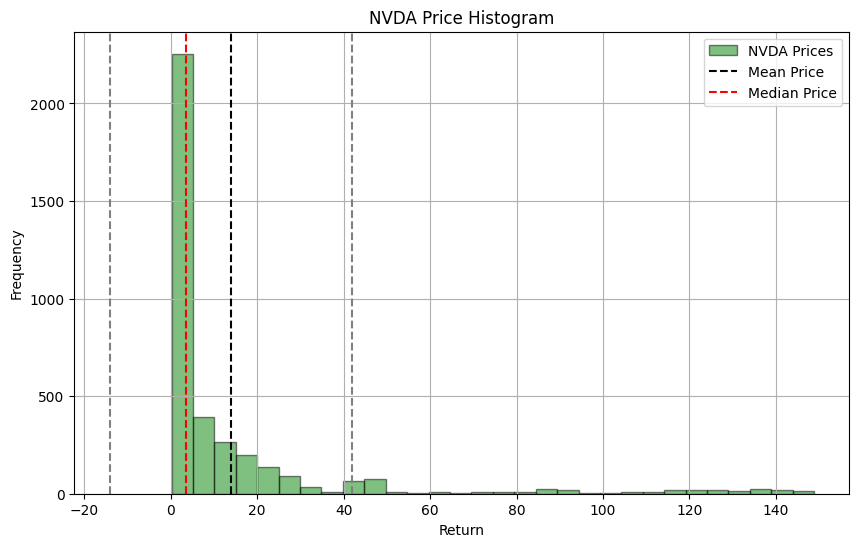

In [23]:
# Create a Histogram of Prices
upper_lim_p = df_prices['NVDA'].mean() + df_prices['NVDA'].std()
lower_lim_p = df_prices['NVDA'].mean() - df_prices['NVDA'].std()

plt.figure(figsize=(10, 6))
plt.hist(df_prices['NVDA'], bins=30, color='green', alpha=0.5, edgecolor='black', label='NVDA Prices')

# Mean and Standard Deviation
plt.axvline(x=df_prices['NVDA'].mean(), color='black', linestyle='dashed', label='Mean Price')
plt.axvline(x=df_prices['NVDA'].median(), color='red', linestyle='dashed', label='Median Price')
plt.axvline(x=upper_lim_p, color='grey', linestyle='dashed')
plt.axvline(x=lower_lim_p, color='grey', linestyle='dashed')

# Config
plt.title('NVDA Price Histogram')
plt.xlabel('Return')
plt.ylabel('Frequency')

# Legend and Grid
plt.legend()
plt.grid(True)

# Show
plt.show()

In [24]:
# Let us count how many observations we find inside one std
stds = 1

upper_lim_p = df_prices['NVDA'].mean() + stds*df_prices['NVDA'].std()
lower_lim_p = df_prices['NVDA'].mean() - stds*df_prices['NVDA'].std()

inside_one_std = df_prices[(df_prices['NVDA'] >= lower_lim_p) & (df_prices['NVDA'] <= upper_lim_p)]

percentage = (len(inside_one_std)/len(df_prices))*100

print(percentage)

90.03709591944886


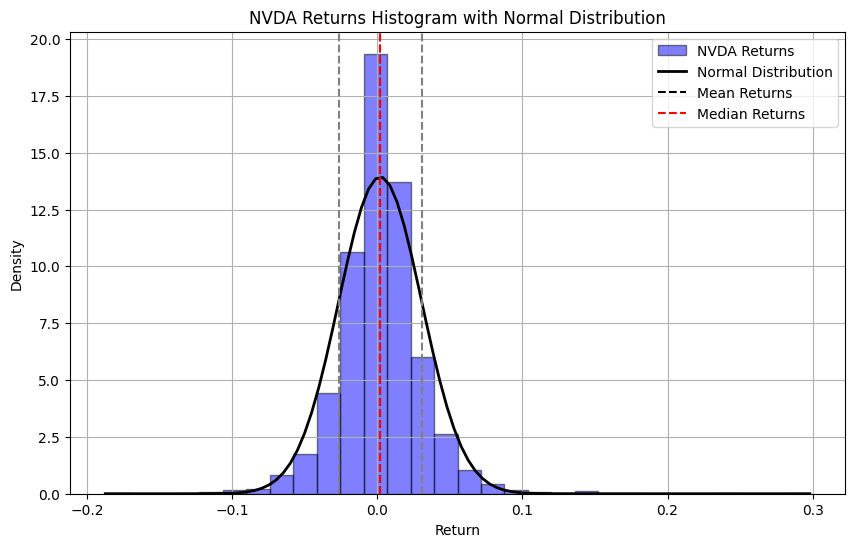

In [25]:
# Calculate Mean and Standard Deviation
mu = df_arithmetic_returns['NVDA'].mean()
sigma = df_arithmetic_returns['NVDA'].std()

# Create Histogram
plt.figure(figsize=(10, 6))
plt.hist(df_arithmetic_returns['NVDA'], bins=30, density=True, color='blue', alpha=0.5, edgecolor='black', label='NVDA Returns')

# Generate the Values of the Normal Distribution
x = np.linspace(df_arithmetic_returns['NVDA'].min(), df_arithmetic_returns['NVDA'].max(), 100)
y = norm.pdf(x, mu, sigma)

# Graph the Real Normal Distribution
plt.plot(x, y, color='black', linestyle='solid', linewidth=2, label='Normal Distribution')

# Reference Lines
plt.axvline(x=mu, color='black', linestyle='dashed', label='Mean Returns')
plt.axvline(x=df_arithmetic_returns['NVDA'].median(), color='red', linestyle='dashed', label='Median Returns')
plt.axvline(x=mu + sigma, color='grey', linestyle='dashed')
plt.axvline(x=mu - sigma, color='grey', linestyle='dashed')

# Config
plt.title('NVDA Returns Histogram with Normal Distribution')
plt.xlabel('Return')
plt.ylabel('Density')

# Legends and Grid
plt.legend()
plt.grid(True)

# Show
plt.show()

In [26]:
# Let us count how many observations we find inside one std
stds = 1

upper_lim = df_arithmetic_returns['NVDA'].mean() + stds*df_arithmetic_returns['NVDA'].std()
lower_lim = df_arithmetic_returns['NVDA'].mean() - stds*df_arithmetic_returns['NVDA'].std()

inside_one_std = df_arithmetic_returns[(df_arithmetic_returns['NVDA'] >= lower_lim) & (df_arithmetic_returns['NVDA'] <= upper_lim)]

percentage = (len(inside_one_std)/len(df_arithmetic_returns))*100

print(percentage)

76.86804451510334


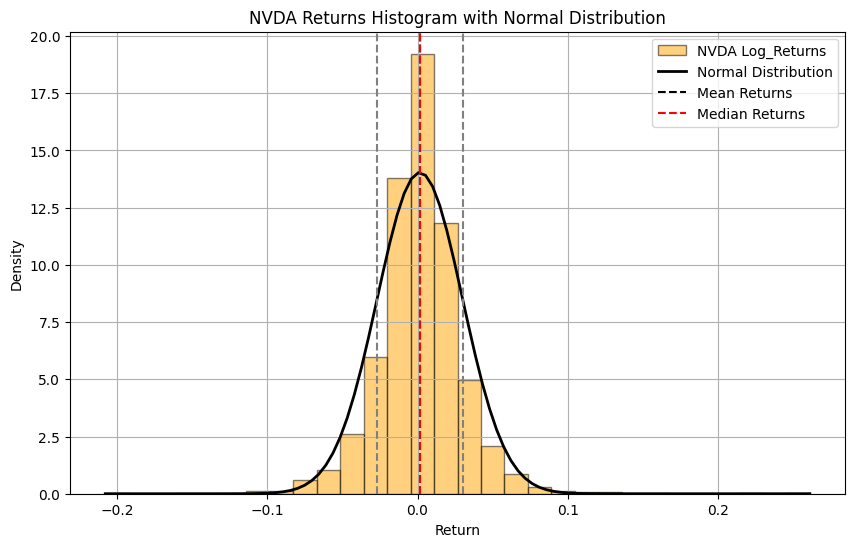

In [27]:
# Calculate Mean and Standard Deviation
mu = df_logarithmic_returns['NVDA'].mean()
sigma = df_logarithmic_returns['NVDA'].std()

# Create Histogram
plt.figure(figsize=(10, 6))
plt.hist(df_logarithmic_returns['NVDA'], bins=30, density=True, color='orange', alpha=0.5, edgecolor='black', label='NVDA Log_Returns')

# Generate the Values of the Normal Distribution
x = np.linspace(df_logarithmic_returns['NVDA'].min(), df_logarithmic_returns['NVDA'].max(), 100)
y = norm.pdf(x, mu, sigma)

# Graph the Real Normal Distribution
plt.plot(x, y, color='black', linestyle='solid', linewidth=2, label='Normal Distribution')

# Reference Lines
plt.axvline(x=mu, color='black', linestyle='dashed', label='Mean Returns')
plt.axvline(x=df_logarithmic_returns['NVDA'].median(), color='red', linestyle='dashed', label='Median Returns')
plt.axvline(x=mu + sigma, color='grey', linestyle='dashed')
plt.axvline(x=mu - sigma, color='grey', linestyle='dashed')

# Config
plt.title('NVDA Returns Histogram with Normal Distribution')
plt.xlabel('Return')
plt.ylabel('Density')

# Legends and Grid
plt.legend()
plt.grid(True)

# Show
plt.show()

In [28]:
# Let us count how many observations we find inside one std
stds = 1

upper_lim = df_logarithmic_returns['NVDA'].mean() + stds*df_logarithmic_returns['NVDA'].std()
lower_lim = df_logarithmic_returns['NVDA'].mean() - stds*df_logarithmic_returns['NVDA'].std()

inside_one_std = df_logarithmic_returns[(df_logarithmic_returns['NVDA'] >= lower_lim) & (df_logarithmic_returns['NVDA'] <= upper_lim)]

percentage = (len(inside_one_std)/len(df_logarithmic_returns))*100

print(percentage)

76.68256491785903


In [29]:
# Calculate Skewness
skewness = skew(df_logarithmic_returns['NVDA'].dropna())

# Calculate Kurtosis
kurt = kurtosis(df_logarithmic_returns['NVDA'].dropna())

print(f"Mean: {df_logarithmic_returns['NVDA'].dropna().mean()}")
print(f"Variance: {df_logarithmic_returns['NVDA'].dropna().var()}")
print(f"Skewness: {skewness}")
print(f"Kurtosis: {kurt}")

Mean: 0.0015261610824865242
Variance: 0.0008077681672253716
Skewness: 0.23487911456620733
Kurtosis: 6.740354985448295


In [30]:
# Normality Test

jb_stat, p_value = jarque_bera(df_logarithmic_returns['NVDA'].dropna())

print(f"Jarque-Bera Stat: {jb_stat}")
print(f"p-value: {p_value}")

Jarque-Bera Stat: 7177.041179195934
p-value: 0.0


In [31]:
# Calculate the JB Stat
n = len(df_logarithmic_returns['NVDA'].dropna())
S = skew(df_logarithmic_returns['NVDA'].dropna())
K = kurtosis(df_logarithmic_returns['NVDA'].dropna(), fisher=False) 

JB_stat = (n / 6) * (S**2 + ((K - 3)**2 / 4))

# Calculate p-value
p_value = 1 - chi2.cdf(JB_stat, df=2)

print(f"JB Stat: {JB_stat}")
print(f"p-value: {p_value}")

JB Stat: 7177.041179195934
p-value: 0.0


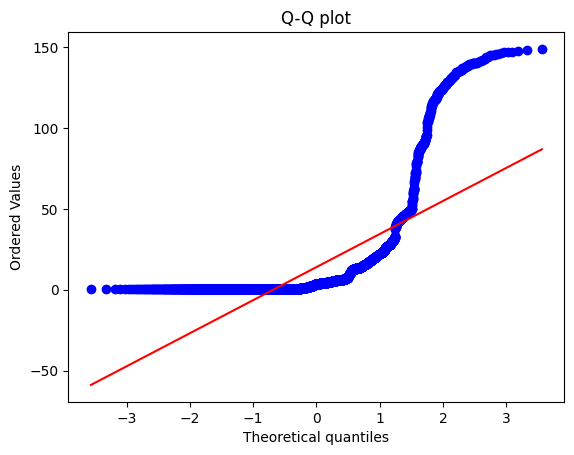

In [32]:
# Prices QQ Plot

probplot(df_prices['NVDA'].dropna(), dist="norm", plot=plt)
plt.title('Q-Q plot')
plt.show()

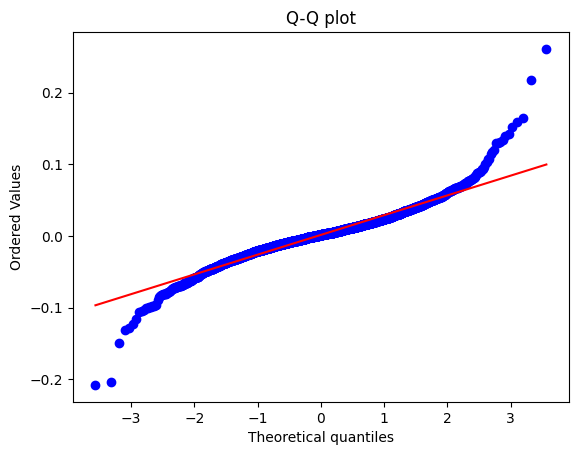

In [33]:
# Returns QQ Plot
probplot(df_logarithmic_returns['NVDA'].dropna(), dist="norm", plot=plt)
plt.title('Q-Q plot')
plt.show()

In [34]:
# Anderson Test
result = anderson(df_logarithmic_returns['NVDA'].dropna())

print(f"Anderson-Darling Stat: {result.statistic}")
print(f"Critical Values: {result.critical_values}")
print(f"Significance Level: {result.significance_level}")

Anderson-Darling Stat: 37.935274530250354
Critical Values: [0.575 0.655 0.786 0.917 1.091]
Significance Level: [15.  10.   5.   2.5  1. ]
